<a href="https://colab.research.google.com/github/angelagdca/GDP_first_model/blob/main/GDP_model_second_try.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PIB España (BISTRO)**

Esto es un forecast del crecimiento del PIB de España (QoQ) que utiliza un modelo de series temporales (BISTRO) alimentado con variables macroeconómicas históricas como producción industrial, consumo (retail), mercado laboral (paro), inflación (HICP) y construcción, para estimar la evolución futura del ciclo económico a partir de patrones aprendidos en los últimos 30 años.

In [ ]:
#Solo 1 vez para no romper el entorno
!pip uninstall -y numpy pandas scipy gluonts uni2ts
!pip install --no-cache-dir --force-reinstall \
    numpy==1.26.4 \
    pandas==2.1.4 \
    scipy==1.11.4
!pip install --no-cache-dir gluonts
!pip install --no-cache-dir uni2ts

Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
Found existing installation: pandas 2.2.2
Uninstalling pandas-2.2.2:
  Successfully uninstalled pandas-2.2.2
Found existing installation: scipy 1.16.3
Uninstalling scipy-1.16.3:
  Successfully uninstalled scipy-1.16.3
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 217.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 265.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 290.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.8/35.8 MB 302.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 229.9/229.9 kB 327.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 510.5/510.5 kB 378.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.5/348.5 kB 328.4 MB/s eta 0:00:00
  Attempting uninstall: pytz
   

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 24.5 MB/s eta 0:00:00
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
    return func(self, options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 447, in run
^C


###**Step 1**

Preparar el entorno y las librerías necesarias para ejecutar BISTRO/Moirai.

In [ ]:
#Deja listo el entorno para usar BISTRO/Moirai

import os
import sys
import subprocess
from pathlib import Path

#Compatibilidad de NumPy (sobre todo en Google Colab)
try:
    import numpy as np

    if np.__version__.startswith("2."):
        print(f"Current NumPy is {np.__version__}. Downgrading to 1.26.4...")

        subprocess.run([
            "pip", "install", "-q", "--force-reinstall",
            "numpy==1.26.4",
            "pandas==2.1.4",
            "scipy==1.11.4",
            "opencv-python==4.8.0.76"
        ], check=True)

        print("✅ Install complete. Restarting runtime automatically...")
        os.kill(os.getpid(), 9)

    else:
        print(f"✅ Success! Using NumPy version: {np.__version__}")

except Exception as e:
    print(f"NumPy compatibility check skipped/error: {e}")

#Si estás en Google Colab: clonar repo e instalar deps

if 'google.colab' in sys.modules:
    print("Running in Google Colab. Cloning BISTRO repo...")

    if not os.path.exists("/content/bistro"):
        !git clone -q https://github.com/bis-med-it/bistro.git

    print("Installing project dependencies...")
    !pip install -q -r /content/bistro/requirements.txt

    print("✅ Repository and dependencies ready.")

✅ Success! Using NumPy version: 1.26.4
Running in Google Colab. Cloning BISTRO repo...
Installing project dependencies...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.2/114.2 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.6/90.6 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 28.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.2/147.2 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.6/44.6 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.8/153.8 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.5/153.5 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.7/536.7 kB 30.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 98.6 MB/s eta 0:00:00
 

In [ ]:
#Ajustar rutas del proyecto

if 'google.colab' in sys.modules:
    project_root = Path("/content/bistro")
else:
    # Cambia esta ruta si trabajas en local
    project_root = Path.cwd()

repo_root = project_root
src_root = repo_root / "src"
script_root = repo_root / "script"

if str(src_root) not in sys.path:
    sys.path.insert(0, str(src_root))

if str(script_root) not in sys.path:
    sys.path.insert(0, str(script_root))

print("repo_root:", repo_root)
print("src_root:", src_root)
print("script_root:", script_root)

#Imports principales
import numpy as np
import pandas as pd

from gluonts.dataset.pandas import PandasDataset
from gluonts.dataset.split import split

from uni2ts.model.moirai import MoiraiForecast, MoiraiModule

from inference_util import plot_publication_forecast_comparison

from preprocessing_util import (
    aggregate_daily_forecast_to_monthly,
    prepare_yoy_monthly_for_daily_inference,
    prepare_long_df_monthly_for_daily_inference
)

print("✅ Core imports loaded successfully.")

repo_root: /content/bistro
src_root: /content/bistro/src
script_root: /content/bistro/script
✅ Core imports loaded successfully.


###**Step 2**

Descargaremos cualquier serie de Eurostat y luego a partir de eso construiremos un df final con el PIB trimestral como target y varias covariables de España: producción industrial (sts_inpr_m), retail (sts_trtu_m), paro mensual (ei_lmhr_m), inflación HICP interanual (prc_hicp_manr), servicios (sts_sepr_m) y construcción (sts_copr_m). Además, Eurostat identifica ei_lmhr_m como la serie derivada de tasa de paro mensual y prc_hicp_manr como la tasa anual del HICP

In [ ]:
import requests
import numpy as np
import pandas as pd

In [94]:
def load_eurostat_series(dataset_code, params, value_name, freq):
    url = f"https://ec.europa.eu/eurostat/api/dissemination/statistics/1.0/data/{dataset_code}"
    r = requests.get(url, params=params, timeout=30)
    r.raise_for_status()
    js = r.json()

    time_key = next(k for k in js["dimension"].keys() if k.lower().startswith("time"))

    time_index = js["dimension"][time_key]["category"]["index"]
    if isinstance(time_index, dict):
        times = [k for k, _ in sorted(time_index.items(), key=lambda x: x[1])]
    else:
        time_labels = js["dimension"][time_key]["category"]["label"]
        times = list(time_labels.keys())

    values_raw = js["value"]
    if isinstance(values_raw, dict):
        values = [values_raw.get(str(i), np.nan) for i in range(len(times))]
    else:
        values = list(values_raw)

    df = pd.DataFrame({
        "date": times,
        value_name: values,
    })

    df[value_name] = pd.to_numeric(df[value_name], errors="coerce")
    df["date"] = pd.PeriodIndex(df["date"], freq=freq)

    df = (
        df.drop_duplicates(subset=["date"], keep="last")
          .set_index("date")
          .sort_index()
    )

    return df

In [116]:
#SERIES DE ESPAÑA

def load_spain_gdp_from_eurostat():
    return load_eurostat_series(
        dataset_code="namq_10_gdp",
        params={
            "lang": "EN",
            "geo": "ES",
            "na_item": "B1GQ",
            "unit": "CLV10_MNAC",
            "s_adj": "SCA",
            "freq": "Q",
        },
        value_name="spain_real_gdp",
        freq="Q",
    )

def load_spain_industrial_production():
    return load_eurostat_series(
        dataset_code="sts_inpr_m",
        params={
            "lang": "EN",
            "geo": "ES",
            "s_adj": "SCA",
            "unit": "I21",
            "nace_r2": "B-D",
            "freq": "M",
        },
        value_name="industrial_prod_index",
        freq="M",
    )

def load_spain_retail_trade():
    return load_eurostat_series(
        dataset_code="ei_isrt_m",
        params={
            "lang": "EN",
            "geo": "ES",
            "s_adj": "SCA",
            "nace_r2": "G47",
            "unit": "I21",
            "freq": "M",
        },
        value_name="retail_trade_index",
        freq="M",
    )

def load_spain_unemployment_rate():
    return load_eurostat_series(
        dataset_code="ei_lmhr_m",
        params={
            "lang": "EN",
            "geo": "ES",
            "s_adj": "SA",
            "unit": "PC_ACT",
            "freq": "M",
        },
        value_name="unemployment_rate",
        freq="M",
    )

def load_spain_hicp_yoy():
    return load_eurostat_series(
        dataset_code="prc_hicp_manr",
        params={
            "lang": "EN",
            "geo": "ES",
            "coicop": "CP00",
            "freq": "M",
        },
        value_name="hicp_yoy",
        freq="M",
    )

def load_spain_services_production():
    return load_eurostat_series(
        dataset_code="sts_sepr_m",
        params={
            "lang": "EN",
            "geo": "ES",
            "s_adj": "SCA",
            "unit": "I21",
            "nace_r2": "H-N_X_K",
            "freq": "M",
        },
        value_name="services_prod_index",
        freq="M",
    )

def load_spain_construction_production():
    return load_eurostat_series(
        dataset_code="sts_copr_m",
        params={
            "lang": "EN",
            "geo": "ES",
            "s_adj": "SCA",
            "unit": "I21",
            "nace_r2": "F",
            "freq": "M",
        },
        value_name="construction_prod_index",
        freq="M",
    )

#PASAR MENSUAL -> TRIMESTRAL
#Construcción del dataset final
def monthly_to_quarterly_mean(df, col_name):
    s = df[col_name].copy()
    s.index = s.index.to_timestamp(how="end")
    s = s.resample("Q").mean()
    s.index = s.index.to_period("Q")
    return s.to_frame(col_name)

def quarterly_qoq(df, col_name, out_name):
    s = df[col_name].pct_change(1) * 100
    return s.to_frame(out_name)

#DESCARGA DE TODAS LAS SERIES
df_gdp = load_spain_gdp_from_eurostat()
df_ipi_m = load_spain_industrial_production()
df_unemp_m = load_spain_unemployment_rate()
df_hicp_m = load_spain_hicp_yoy()
#df_services_m = load_spain_services_production()
df_constr_m = load_spain_construction_production()
df_retail_m = load_spain_retail_trade()

for name, obj in {
    "df_ipi_m": df_ipi_m,
    "df_retail_m": df_retail_m,
    "df_unemp_m": df_unemp_m,
    "df_hicp_m": df_hicp_m,
    #"df_services_m": df_services_m,
    "df_constr_m": df_constr_m,
}.items():
    if obj.empty:
        raise ValueError(f"{name} está vacío.")


#TRANSFORMACIONES A FRECUENCIA TRIMESTRAL

df_ipi_q_avg = monthly_to_quarterly_mean(df_ipi_m, "industrial_prod_index")
df_retail_q_avg = monthly_to_quarterly_mean(df_retail_m, "retail_trade_index")
#df_services_q_avg = monthly_to_quarterly_mean(df_services_m, "services_prod_index")
df_constr_q_avg = monthly_to_quarterly_mean(df_constr_m, "construction_prod_index")

df_ipi_q = quarterly_qoq(df_ipi_q_avg, "industrial_prod_index", "ipi_qoq")
df_retail_q = quarterly_qoq(df_retail_q_avg, "retail_trade_index", "retail_qoq")
#df_services_q = quarterly_qoq(df_services_q_avg, "services_prod_index")
df_constr_q = quarterly_qoq(df_constr_q_avg, "construction_prod_index", "construction_qoq")

df_unemp_q = monthly_to_quarterly_mean(df_unemp_m, "unemployment_rate").rename(
    columns={"unemployment_rate": "unemp_rate"}
)
df_hicp_q = monthly_to_quarterly_mean(df_hicp_m, "hicp_yoy")

In [127]:
#DATASET FINAL DEL MODELO

df = pd.concat(
    [
        df_gdp,
        df_ipi_q,
        df_retail_q,
        df_unemp_q,
        df_hicp_q,
        #df_services_q,
        df_constr_q,
    ],
    axis=1
).sort_index()

print("Cobertura inicial:")
print(df.notna().sum())
display(df.head())
display(df.tail())

csv_path = "spain_gdp_with_covariates_latest.csv"
df.to_csv(csv_path)

print(f"CSV actualizado guardado en: {csv_path}")
print("Columnas disponibles:", df.columns.tolist())

Cobertura inicial:
spain_real_gdp      124
ipi_qoq             136
retail_qoq          104
unemp_rate          160
hicp_yoy            116
construction_qoq     84
dtype: int64


,spain_real_gdp,ipi_qoq,retail_qoq,unemp_rate,hicp_yoy,construction_qoq
date,,,,,,
1953Q1,NaN,NaN,NaN,NaN,NaN,NaN
1953Q2,NaN,NaN,NaN,NaN,NaN,NaN
1953Q3,NaN,NaN,NaN,NaN,NaN,NaN
1953Q4,NaN,NaN,NaN,NaN,NaN,NaN
1954Q1,NaN,NaN,NaN,NaN,NaN,NaN


,spain_real_gdp,ipi_qoq,retail_qoq,unemp_rate,hicp_yoy,construction_qoq
date,,,,,,
2025Q1,326054.0,0.295761,1.211340,10.866667,2.666667,18.075899
2025Q2,328474.4,0.557012,1.680672,10.600000,2.166667,3.552298
2025Q3,330587.9,0.130336,1.227148,10.500000,2.800000,0.190580
2025Q4,333321.7,0.683371,1.434933,10.100000,3.133333,2.472826
2026Q1,NaN,-1.777634,0.170732,9.800000,NaN,-5.011933


CSV actualizado guardado en: spain_gdp_with_covariates_latest.csv
Columnas disponibles: ['spain_real_gdp', 'ipi_qoq', 'retail_qoq', 'unemp_rate', 'hicp_yoy', 'construction_qoq']


Limpiamos y preparamos la serie de PIB

In [118]:
# LIMPIAMOS Y PREPARAMOS EL DATASET FINAL PARA EL MODELO
df_model = df.copy()
df_model = df_model.rename(columns={"spain_real_gdp": "gdp_real"})

# Crear crecimiento trimestral del PIB en %
df_model["gdp_qoq"] = df_model["gdp_real"].pct_change() * 100

# Target y covariables
target_col = "gdp_qoq"
cov_level_cols = [
    "ipi_qoq",
    "retail_qoq",
    "unemp_rate",
    "hicp_yoy",
    "construction_qoq",
]

# forward fill solo para covariables
df_model[cov_level_cols] = df_model[cov_level_cols].ffill()

# target
df_model["gdp_qoq"] = df_model["gdp_real"].pct_change() * 100

target_col = "gdp_qoq"
covariate_cols = cov_level_cols.copy()

# Aquí sí: quedarse solo con columnas necesarias
df_model = df_model[["gdp_real", target_col] + covariate_cols]

# Eliminar solo filas donde falte el target o siga faltando algo imprescindible
df_model = df_model.dropna(subset=["gdp_real", target_col])

print("Número de observaciones finales:", len(df_model))
print("Primer periodo:", df_model.index.min())
print("Último periodo:", df_model.index.max())
display(df_model.head())
display(df_model.tail())

Número de observaciones finales: 123
Primer periodo: 1995Q2
Último periodo: 2025Q4


/tmp/ipykernel_6073/1394604270.py:6: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df_model["gdp_qoq"] = df_model["gdp_real"].pct_change() * 100
/tmp/ipykernel_6073/1394604270.py:22: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df_model["gdp_qoq"] = df_model["gdp_real"].pct_change() * 100


,gdp_real,gdp_qoq,ipi_qoq,retail_qoq,unemp_rate,hicp_yoy,construction_qoq
date,,,,,,,
1995Q2,179766.0,0.659168,0.526662,NaN,20.566667,NaN,NaN
1995Q3,180561.7,0.442631,-1.375246,NaN,20.800000,NaN,NaN
1995Q4,181928.6,0.757027,-0.199203,NaN,20.633333,NaN,NaN
1996Q1,182974.5,0.574896,-0.731870,NaN,20.333333,NaN,NaN
1996Q2,184239.5,0.691353,-0.234584,NaN,20.133333,NaN,NaN


,gdp_real,gdp_qoq,ipi_qoq,retail_qoq,unemp_rate,hicp_yoy,construction_qoq
date,,,,,,,
2024Q4,324467.2,0.813581,1.365756,0.936524,10.833333,2.333333,0.805369
2025Q1,326054.0,0.489048,0.295761,1.211340,10.866667,2.666667,18.075899
2025Q2,328474.4,0.742331,0.557012,1.680672,10.600000,2.166667,3.552298
2025Q3,330587.9,0.643429,0.130336,1.227148,10.500000,2.800000,0.190580
2025Q4,333321.7,0.826951,0.683371,1.434933,10.100000,3.133333,2.472826


###**Step 3**

Definir la estructura del forecast: horizonte, ventana histórica y división entre train y test.

- Horizonte de forecast
- Longitud de contexto
- Serie objetivo en el formato correcto
- Punto desde el que queremos predecir

Frequency: Q
Prediction length: 4
Context length: 12
Último dato observado: 2025Q4
Forecast empieza en: 2026Q1


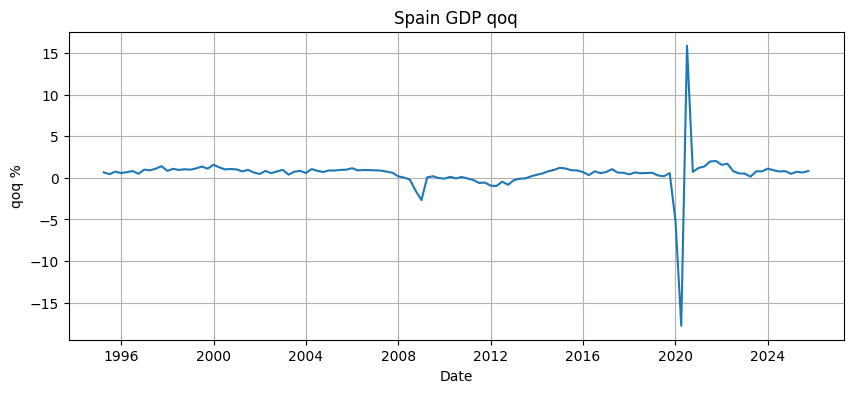

In [119]:
import matplotlib.pyplot as plt
import pandas as pd

#Parámetros del forecast
FREQ = "Q"
PDT = 4   # 4 trimestres
CTX = 12  # 12 trimestres de contexto
BSZ = 32
PSZ = 8

print("Frequency:", FREQ)
print("Prediction length:", PDT)
print("Context length:", CTX)

#Serie objetivo final
ts = df_model[target_col].copy()

#Forecast para 2026
forecast_start = pd.Period("2026Q1", freq=FREQ)

print("Último dato observado:", ts.index[-1])
print("Forecast empieza en:", forecast_start)

#Visualización rápida de la serie
plt.figure(figsize=(10, 4))
plt.plot(ts.index.to_timestamp(), ts.values)
plt.title("Spain GDP qoq")
plt.xlabel("Date")
plt.ylabel("qoq %")
plt.grid(True)
plt.show()

Convertimos la serie trimestral a un dataframe compatible con el pipeline de forecasting

In [ ]:
!pip install gluonts
from gluonts.dataset.pandas import PandasDataset

In [120]:
FORECAST_START_DATE = "2026Q1"
ROLLING_WINDOWS = 1
WINDOW_DISTANCE = 1

df_bistro = df_model.copy()
df_bistro["item_id"] = "spain_gdp"

if len(df_bistro) <= CTX + PDT:
    raise ValueError(
        f"No hay suficiente historia para CTX={CTX} y PDT={PDT}. "
        f"Observaciones disponibles: {len(df_bistro)}"
    )

prep = prepare_long_df_monthly_for_daily_inference(
    df_bistro,
    item_id_col="item_id",
    target_col=target_col,
    past_dynamic_real_cols=covariate_cols,
    freq=FREQ,
    forecast_start_date=FORECAST_START_DATE,
    pdt_patches=PDT,
    ctx_patches=CTX,
    steps_per_period=PSZ,
    rolling_windows=ROLLING_WINDOWS,
    window_distance_patches=WINDOW_DISTANCE,
)

last_actual_period = prep.df_dt.index.max().to_period(FREQ)
pure_future_forecast = prep.forecast_start > last_actual_period
forecast_windows = 1 if pure_future_forecast else prep.windows

if (not pure_future_forecast) and (prep.windows < 1):
    raise ValueError(
        f"Not enough test data after cutoff {prep.train_end} to create a window: "
        f"test_len={(prep.df_dt.index > prep.cutoff_date_dt).sum()} periods, PDT={PDT}."
    )

ds = PandasDataset.from_long_dataframe(
    prep.daily_long_df,
    item_id="item_id",
    target=target_col,
    past_feat_dynamic_real=covariate_cols,
    feat_dynamic_real=[],
)

train, test_template = split(ds, date=prep.cutoff_period_daily)

test_data = test_template.generate_instances(
    prediction_length=prep.pdt_steps,
    windows=forecast_windows,
    distance=prep.dist_steps,
    max_history=prep.ctx_steps,
)

print("Último dato observado:", last_actual_period)
print("Forecast start:", prep.forecast_start)
print("Pure future forecast:", pure_future_forecast)
print("Número de ventanas:", forecast_windows)
print("Prediction length interna:", prep.pdt_steps)
print("Context length interna:", prep.ctx_steps)
print("Número de covariables:", len(covariate_cols))

Último dato observado: 2025Q4
Forecast start: 2026Q1
Pure future forecast: True
Número de ventanas: 1
Prediction length interna: 32
Context length interna: 96
Número de covariables: 5


###**Step 4**

Ejecutar la predicción con BISTRO sobre el PIB de España incluyendo las covariables y comparar el forecast con los datos reales.

In [55]:
import os
from pathlib import Path

if not Path("/content/bistro").exists():
    !git clone -q https://github.com/bis-med-it/bistro.git /content/bistro

!pip install -q -r /content/bistro/requirements.txt

In [56]:
import os
import sys
from pathlib import Path

os.chdir("/content/bistro/script")

repo_root_bistro = Path("..").resolve()
src_root = Path("../src").resolve()

if str(src_root) not in sys.path:
    sys.path.insert(0, str(src_root))

print("repo_root_bistro:", repo_root_bistro)
print("src_root:", src_root)

repo_root_bistro: /content/bistro
src_root: /content/bistro/src


In [30]:
#IMPORTS

import numpy as np
import pandas as pd
from gluonts.dataset.pandas import PandasDataset
from gluonts.dataset.split import split
from uni2ts.model.moirai import MoiraiForecast, MoiraiModule


In [121]:
#Ejecutamos BISTRO

MODEL_REPO = Path("/content/bistro/bistro-finetuned")

model = MoiraiForecast(
    module=MoiraiModule.from_pretrained(str(MODEL_REPO)),
    prediction_length=int(prep.pdt_steps),
    context_length=int(prep.ctx_steps),
    patch_size=int(PSZ),
    num_samples=100,
    target_dim=1,
    feat_dynamic_real_dim=0,
    past_feat_dynamic_real_dim=len(covariate_cols),
)

predictor = model.create_predictor(batch_size=BSZ)
inputs = list(test_data.input)
labels = list(test_data.label)
forecasts = list(predictor.predict(test_data.input))

print("Número de forecasts generados:", len(forecasts))

bistro_forecast_by_window = {}
rmse_rows = []

for w in range(forecast_windows):
    samples = np.asarray(forecasts[w].samples, dtype=float)

    if w < len(labels) and isinstance(labels[w], dict) and "target" in labels[w]:
        label_target = np.asarray(labels[w]["target"], dtype=float)
    else:
        label_target = np.asarray([], dtype=float)

    if w < len(inputs) and isinstance(inputs[w], dict) and "target" in inputs[w]:
        inp_target = np.asarray(inputs[w]["target"], dtype=float)
    else:
        inp_target = np.asarray([], dtype=float)

    last_input = float(inp_target[-1]) if inp_target.size > 0 else None

    preds, _, ci = aggregate_daily_forecast_to_monthly(
        samples,
        label_target,
        last_input,
        steps_per_period=PSZ,
        expected_periods=PDT,
    )

    pred_index = pd.period_range(
        start=prep.forecast_start + w * WINDOW_DISTANCE,
        periods=PDT,
        freq=FREQ,
    )

    dfw = pd.DataFrame(
        {
            "bistro_pred": preds,
            "bistro_lo": ci[:, 0],
            "bistro_hi": ci[:, 1],
        },
        index=pred_index,
    )

    bistro_forecast_by_window[w] = dfw

    actual = df_model[target_col].reindex(pred_index).astype(float)
    pred = dfw["bistro_pred"].astype(float)
    valid = actual.notna() & pred.notna()

    rmse = float(np.sqrt(np.mean((pred[valid] - actual[valid]) ** 2))) if valid.any() else np.nan

    rmse_rows.append(
        {
            "window": w,
            "forecast_start": pred_index[0],
            "forecast_end": pred_index[-1],
            "rmse": rmse,
            "n_valid": int(valid.sum()),
        }
    )

rmse_table = pd.DataFrame(rmse_rows)

print("Resumen de ventanas:")
display(rmse_table)

forecast_2026 = bistro_forecast_by_window[0].copy()
forecast_2026 = forecast_2026.loc["2026Q1":"2026Q4"]

print("Forecast QoQ de España para 2026:")
display(forecast_2026)


Loading weights from local directory
Número de forecasts generados: 1
Resumen de ventanas:


,window,forecast_start,forecast_end,rmse,n_valid
0,0,2026Q1,2026Q4,NaN,0


Forecast QoQ de España para 2026:


,bistro_pred,bistro_lo,bistro_hi
2026Q1,0.734029,0.686123,0.877106
2026Q2,0.750115,0.688938,0.864200
2026Q3,0.743461,0.698491,0.861953
2026Q4,0.749135,0.698487,0.877089


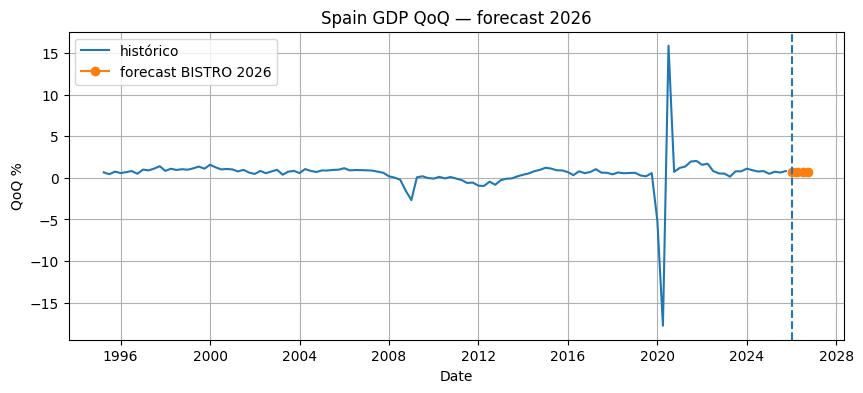

In [122]:
#Gráfico del forecast 2026

import matplotlib.pyplot as plt
import pandas as pd

hist = df_model[target_col].copy()

plt.figure(figsize=(10, 4))

# Histórico
plt.plot(
    hist.index.to_timestamp(),
    hist.values,
    label="histórico"
)

# Forecast 2026
plt.plot(
    forecast_2026.index.to_timestamp(),
    forecast_2026["bistro_pred"].values,
    marker="o",
    label="forecast BISTRO 2026"
)

# Bandas de confianza
plt.fill_between(
    forecast_2026.index.to_timestamp(),
    forecast_2026["bistro_lo"].values,
    forecast_2026["bistro_hi"].values,
    alpha=0.2
)

# Línea vertical donde empieza el forecast
plt.axvline(pd.Period("2026Q1", freq="Q").to_timestamp(), linestyle="--")

plt.title("Spain GDP QoQ — forecast 2026")
plt.xlabel("Date")
plt.ylabel("QoQ %")
plt.grid(True)
plt.legend()
plt.show()

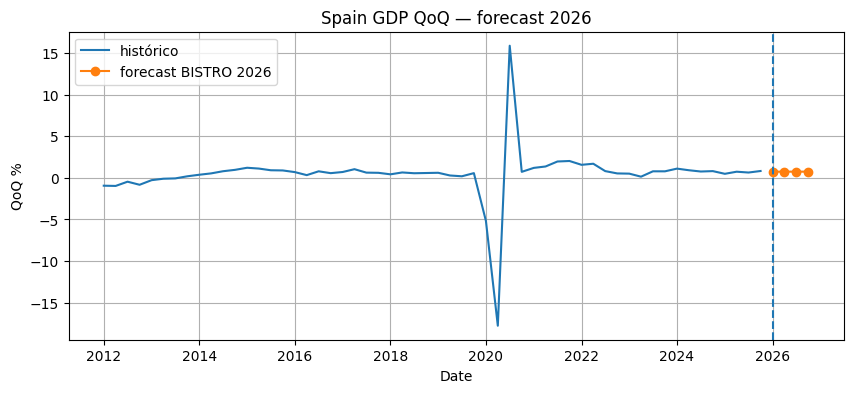

In [123]:
#Gráfico del forecast 2026
hist = df_model[target_col].copy()
hist = hist.loc["2012Q1":]

plt.figure(figsize=(10, 4))

plt.plot(
    hist.index.to_timestamp(),
    hist.values,
    label="histórico"
)

plt.plot(
    forecast_2026.index.to_timestamp(),
    forecast_2026["bistro_pred"].values,
    marker="o",
    label="forecast BISTRO 2026"
)

plt.fill_between(
    forecast_2026.index.to_timestamp(),
    forecast_2026["bistro_lo"].values,
    forecast_2026["bistro_hi"].values,
    alpha=0.2
)

plt.axvline(pd.Period("2026Q1", freq="Q").to_timestamp(), linestyle="--")

plt.title("Spain GDP QoQ — forecast 2026")
plt.xlabel("Date")
plt.ylabel("QoQ %")
plt.grid(True)
plt.legend()
plt.show()

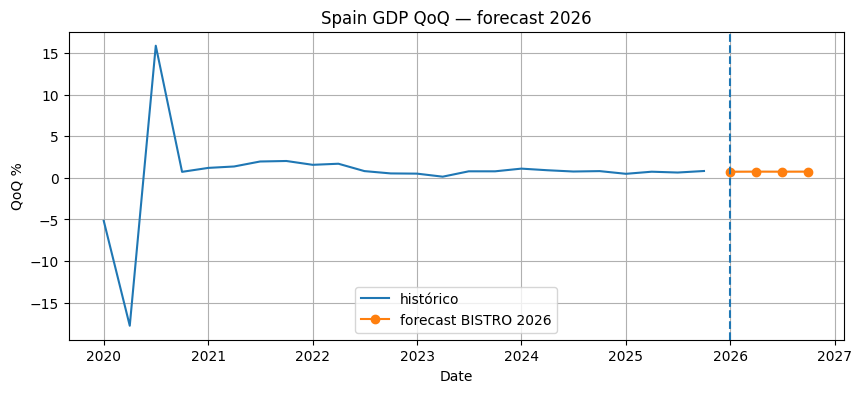

In [124]:
#Gráfico del forecast 2026
hist = df_model[target_col].copy()
hist = hist.loc["2020Q1":]

plt.figure(figsize=(10, 4))

plt.plot(
    hist.index.to_timestamp(),
    hist.values,
    label="histórico"
)

plt.plot(
    forecast_2026.index.to_timestamp(),
    forecast_2026["bistro_pred"].values,
    marker="o",
    label="forecast BISTRO 2026"
)

plt.fill_between(
    forecast_2026.index.to_timestamp(),
    forecast_2026["bistro_lo"].values,
    forecast_2026["bistro_hi"].values,
    alpha=0.2
)

plt.axvline(pd.Period("2026Q1", freq="Q").to_timestamp(), linestyle="--")

plt.title("Spain GDP QoQ — forecast 2026")
plt.xlabel("Date")
plt.ylabel("QoQ %")
plt.grid(True)
plt.legend()
plt.show()

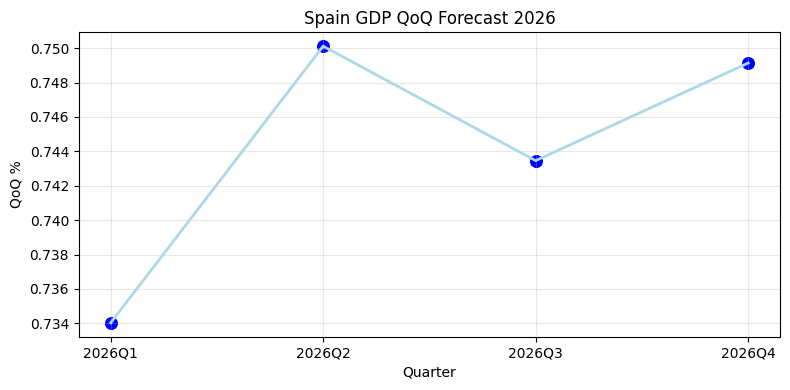

In [125]:
import matplotlib.pyplot as plt

x = forecast_2026.index.astype(str)   # '2026Q1', '2026Q2'...
y = forecast_2026["bistro_pred"].values

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x, y, linewidth=2, color="lightblue")
ax.scatter(x, y, s=70, color="blue")
ax.set_title("Spain GDP QoQ Forecast 2026")
ax.set_xlabel("Quarter")
ax.set_ylabel("QoQ %")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [126]:
print("Número de observaciones:", len(df_model))
print("Primer periodo:", df_model.index.min())
print("Último periodo:", df_model.index.max())
print()
print(df_model[covariate_cols].isna().sum())

Número de observaciones: 123
Primer periodo: 1995Q2
Último periodo: 2025Q4

ipi_qoq              0
retail_qoq          20
unemp_rate           0
hicp_yoy             7
construction_qoq    40
dtype: int64


In [129]:
df_1995_2025 = df.loc["1995Q1":"2025Q4"]
display(df_1995_2025)

,spain_real_gdp,ipi_qoq,retail_qoq,unemp_rate,hicp_yoy,construction_qoq
date,,,,,,
1995Q1,178588.8,1.300433,NaN,21.166667,NaN,NaN
1995Q2,179766.0,0.526662,NaN,20.566667,NaN,NaN
1995Q3,180561.7,-1.375246,NaN,20.800000,NaN,NaN
1995Q4,181928.6,-0.199203,NaN,20.633333,NaN,NaN
1996Q1,182974.5,-0.731870,NaN,20.333333,NaN,NaN
...,...,...,...,...,...,...
2024Q4,324467.2,1.365756,0.936524,10.833333,2.333333,0.805369
2025Q1,326054.0,0.295761,1.211340,10.866667,2.666667,18.075899
2025Q2,328474.4,0.557012,1.680672,10.600000,2.166667,3.552298


###**Comparación 1995 y 2005**

En la siguiente parte vamos a analizar si los datos son mejores a partir del 2005 evitando valores Nan del modelo, comparando con los valores a partir de 1995.

In [130]:
df_model_1995 = df_model.loc["1995Q1":"2025Q4"].copy()
df_model_2005 = df_model.loc["2005Q1":"2025Q4"].copy()

print("1995:", len(df_model_1995), df_model_1995.index.min(), df_model_1995.index.max())
print("2005:", len(df_model_2005), df_model_2005.index.min(), df_model_2005.index.max())

1995: 123 1995Q2 2025Q4
2005: 84 2005Q1 2025Q4


In [131]:
def run_backtest(df_model_in, model_repo, target_col, covariate_cols,
                 freq="Q", forecast_start_date="2023Q1",
                 pdt=4, ctx=12, psz=8, bsz=32,
                 rolling_windows=8, window_distance=1, num_samples=100):

    df_bistro = df_model_in.copy()
    df_bistro["item_id"] = "spain_gdp"

    if len(df_bistro) <= ctx + pdt:
        raise ValueError(
            f"No hay suficiente historia para CTX={ctx} y PDT={pdt}. "
            f"Observaciones disponibles: {len(df_bistro)}"
        )

    prep = prepare_long_df_monthly_for_daily_inference(
        df_bistro,
        item_id_col="item_id",
        target_col=target_col,
        past_dynamic_real_cols=covariate_cols,
        freq=freq,
        forecast_start_date=forecast_start_date,
        pdt_patches=pdt,
        ctx_patches=ctx,
        steps_per_period=psz,
        rolling_windows=rolling_windows,
        window_distance_patches=window_distance,
    )

    last_actual_period = prep.df_dt.index.max().to_period(freq)
    pure_future_forecast = prep.forecast_start > last_actual_period
    forecast_windows = 1 if pure_future_forecast else prep.windows

    ds = PandasDataset.from_long_dataframe(
        prep.daily_long_df,
        item_id="item_id",
        target=target_col,
        past_feat_dynamic_real=covariate_cols,
        feat_dynamic_real=[],
    )

    train, test_template = split(ds, date=prep.cutoff_period_daily)

    test_data = test_template.generate_instances(
        prediction_length=prep.pdt_steps,
        windows=forecast_windows,
        distance=prep.dist_steps,
        max_history=prep.ctx_steps,
    )

    model = MoiraiForecast(
        module=MoiraiModule.from_pretrained(str(model_repo)),
        prediction_length=int(prep.pdt_steps),
        context_length=int(prep.ctx_steps),
        patch_size=int(psz),
        num_samples=num_samples,
        target_dim=1,
        feat_dynamic_real_dim=0,
        past_feat_dynamic_real_dim=len(covariate_cols),
    )

    predictor = model.create_predictor(batch_size=bsz)

    inputs = list(test_data.input)
    labels = list(test_data.label)
    forecasts = list(predictor.predict(test_data.input))

    rows = []

    for w in range(forecast_windows):
        samples = np.asarray(forecasts[w].samples, dtype=float)

        if w < len(labels) and isinstance(labels[w], dict) and "target" in labels[w]:
            label_target = np.asarray(labels[w]["target"], dtype=float)
        else:
            label_target = np.asarray([], dtype=float)

        if w < len(inputs) and isinstance(inputs[w], dict) and "target" in inputs[w]:
            inp_target = np.asarray(inputs[w]["target"], dtype=float)
        else:
            inp_target = np.asarray([], dtype=float)

        last_input = float(inp_target[-1]) if inp_target.size > 0 else None

        preds, _, ci = aggregate_daily_forecast_to_monthly(
            samples,
            label_target,
            last_input,
            steps_per_period=psz,
            expected_periods=pdt,
        )

        pred_index = pd.period_range(
            start=prep.forecast_start + w * window_distance,
            periods=pdt,
            freq=freq,
        )

        pred = pd.Series(preds, index=pred_index, dtype=float)
        actual = df_model_in[target_col].reindex(pred_index).astype(float)

        prev_period = pred_index[0] - 1
        if prev_period in df_model_in.index:
            naive = pd.Series(float(df_model_in.loc[prev_period, target_col]), index=pred_index)
        else:
            naive = pd.Series(np.nan, index=pred_index)

        valid = actual.notna() & pred.notna()
        valid_naive = actual.notna() & naive.notna()

        if valid.sum() > 0:
            errors = pred[valid] - actual[valid]
            rmse = float(np.sqrt(np.mean(errors**2)))
            mae = float(np.mean(np.abs(errors)))
            bias = float(np.mean(errors))
            dir_acc = float(np.mean(np.sign(pred[valid]) == np.sign(actual[valid])))
        else:
            rmse = np.nan
            mae = np.nan
            bias = np.nan
            dir_acc = np.nan

        if valid_naive.sum() > 0:
            naive_errors = naive[valid_naive] - actual[valid_naive]
            naive_rmse = float(np.sqrt(np.mean(naive_errors**2)))
            naive_mae = float(np.mean(np.abs(naive_errors)))
        else:
            naive_rmse = np.nan
            naive_mae = np.nan

        rows.append({
            "window": w,
            "forecast_start": pred_index[0],
            "forecast_end": pred_index[-1],
            "n_obs": int(valid.sum()),
            "rmse_bistro": rmse,
            "mae_bistro": mae,
            "bias_bistro": bias,
            "directional_accuracy": dir_acc,
            "rmse_naive": naive_rmse,
            "mae_naive": naive_mae,
        })

    backtest_table = pd.DataFrame(rows)

    summary = pd.DataFrame({
        "metric": [
            "avg_rmse_bistro",
            "avg_mae_bistro",
            "avg_bias_bistro",
            "avg_directional_accuracy",
            "avg_rmse_naive",
            "avg_mae_naive",
        ],
        "value": [
            backtest_table["rmse_bistro"].mean(),
            backtest_table["mae_bistro"].mean(),
            backtest_table["bias_bistro"].mean(),
            backtest_table["directional_accuracy"].mean(),
            backtest_table["rmse_naive"].mean(),
            backtest_table["mae_naive"].mean(),
        ]
    })

    return backtest_table, summary

In [132]:
MODEL_REPO = Path("/content/bistro/bistro-finetuned")

target_col = "gdp_qoq"
covariate_cols = ["ipi_qoq", "retail_qoq", "unemp_rate", "hicp_yoy", "construction_qoq"]

bt_1995, sum_1995 = run_backtest(
    df_model_1995,
    model_repo=MODEL_REPO,
    target_col=target_col,
    covariate_cols=covariate_cols,
    freq="Q",
    forecast_start_date="2023Q1",
    pdt=4,
    ctx=12,
    psz=8,
    bsz=32,
    rolling_windows=8,
    window_distance=1,
)

bt_2005, sum_2005 = run_backtest(
    df_model_2005,
    model_repo=MODEL_REPO,
    target_col=target_col,
    covariate_cols=covariate_cols,
    freq="Q",
    forecast_start_date="2023Q1",
    pdt=4,
    ctx=12,
    psz=8,
    bsz=32,
    rolling_windows=8,
    window_distance=1,
)

print("Backtest 1995")
display(bt_1995)
display(sum_1995)

print("Backtest 2005")
display(bt_2005)
display(sum_2005)

Loading weights from local directory
Loading weights from local directory
Backtest 1995


,window,forecast_start,forecast_end,n_obs,rmse_bistro,mae_bistro,bias_bistro,directional_accuracy,rmse_naive,mae_naive
0,0,2023Q1,2023Q4,4,1.194471,1.164387,1.164387,1.0,0.265787,0.231084
1,1,2023Q2,2024Q1,4,0.944184,0.887503,0.887503,1.0,0.404222,0.381859
2,2,2023Q3,2024Q2,4,0.654450,0.642091,0.642091,1.0,0.770195,0.758693
3,3,2023Q4,2024Q3,4,0.633470,0.617185,0.617185,1.0,0.174516,0.119611
4,4,2024Q1,2024Q4,4,0.591423,0.572680,0.572680,1.0,0.175799,0.125897
5,5,2024Q2,2025Q1,4,0.725767,0.701927,0.701927,1.0,0.399363,0.366435
6,6,2024Q3,2025Q2,4,0.682976,0.675567,0.675567,1.0,0.250368,0.216403
7,7,2024Q4,2025Q3,4,0.630736,0.619468,0.619468,1.0,0.153242,0.117280


,metric,value
0,avg_rmse_bistro,0.757184
1,avg_mae_bistro,0.735101
2,avg_bias_bistro,0.735101
3,avg_directional_accuracy,1.000000
4,avg_rmse_naive,0.324186
5,avg_mae_naive,0.289658


Backtest 2005


,window,forecast_start,forecast_end,n_obs,rmse_bistro,mae_bistro,bias_bistro,directional_accuracy,rmse_naive,mae_naive
0,0,2023Q1,2023Q4,4,1.194291,1.168254,1.168254,1.0,0.265787,0.231084
1,1,2023Q2,2024Q1,4,0.925001,0.851885,0.851885,1.0,0.404222,0.381859
2,2,2023Q3,2024Q2,4,0.633344,0.618640,0.618640,1.0,0.770195,0.758693
3,3,2023Q4,2024Q3,4,0.648768,0.630211,0.630211,1.0,0.174516,0.119611
4,4,2024Q1,2024Q4,4,0.596444,0.581384,0.581384,1.0,0.175799,0.125897
5,5,2024Q2,2025Q1,4,0.686358,0.662923,0.662923,1.0,0.399363,0.366435
6,6,2024Q3,2025Q2,4,0.699608,0.685717,0.685717,1.0,0.250368,0.216403
7,7,2024Q4,2025Q3,4,0.668091,0.653422,0.653422,1.0,0.153242,0.117280


,metric,value
0,avg_rmse_bistro,0.756488
1,avg_mae_bistro,0.731554
2,avg_bias_bistro,0.731554
3,avg_directional_accuracy,1.000000
4,avg_rmse_naive,0.324186
5,avg_mae_naive,0.289658


In [133]:
comparison = pd.DataFrame({
    "sample_start": ["1995Q1", "2005Q1"],
    "n_obs": [len(df_model_1995), len(df_model_2005)],
    "avg_rmse_bistro": [
        sum_1995.loc[sum_1995["metric"] == "avg_rmse_bistro", "value"].iloc[0],
        sum_2005.loc[sum_2005["metric"] == "avg_rmse_bistro", "value"].iloc[0],
    ],
    "avg_mae_bistro": [
        sum_1995.loc[sum_1995["metric"] == "avg_mae_bistro", "value"].iloc[0],
        sum_2005.loc[sum_2005["metric"] == "avg_mae_bistro", "value"].iloc[0],
    ],
    "avg_bias_bistro": [
        sum_1995.loc[sum_1995["metric"] == "avg_bias_bistro", "value"].iloc[0],
        sum_2005.loc[sum_2005["metric"] == "avg_bias_bistro", "value"].iloc[0],
    ],
    "avg_directional_accuracy": [
        sum_1995.loc[sum_1995["metric"] == "avg_directional_accuracy", "value"].iloc[0],
        sum_2005.loc[sum_2005["metric"] == "avg_directional_accuracy", "value"].iloc[0],
    ],
    "avg_rmse_naive": [
        sum_1995.loc[sum_1995["metric"] == "avg_rmse_naive", "value"].iloc[0],
        sum_2005.loc[sum_2005["metric"] == "avg_rmse_naive", "value"].iloc[0],
    ],
})

display(comparison)

,sample_start,n_obs,avg_rmse_bistro,avg_mae_bistro,avg_bias_bistro,avg_directional_accuracy,avg_rmse_naive
0,1995Q1,123,0.757184,0.735101,0.735101,1.0,0.324186
1,2005Q1,84,0.756488,0.731554,0.731554,1.0,0.324186


El modelo presenta resultados muy similares utilizando datos desde 1995 o desde 2005, lo que indica que añadir más historia no mejora significativamente su capacidad predictiva; en ambos casos el error (RMSE 0,75) es prácticamente igual. Sin embargo, el hecho de que el error sea claramente superior al del modelo naive (0,32) sugiere que el modelo no está aportando valor predictivo adicional y, aunque acierta bien la dirección del ciclo (100%), lo hace probablemente de forma trivial replicando la tendencia reciente. En conjunto, el modelo es estable pero todavía débil en términos de precisión y necesita mejoras para superar a un benchmark simple.